In [1]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION PIPELINE — REPORT OVERALL (FULL-PERIOD) SKILL
=================================================================

What changed vs your script
---------------------------
You asked: "overall best r2/corr for the whole historical period, not just the test period."

This version keeps your exact approach (train-only EOF basis; CV inside trainval; leakage-safe ranking;
final fit on trainval; calibration fitted on trainval preds only), but it ALSO computes:

  - overall_r2 / overall_corr : metrics over ALL YEARS USED (trainval + test, after lag loss)
  - trainval_r2 / trainval_corr
  - test_r2 / test_corr

Important nuance (so you interpret it correctly)
------------------------------------------------
Overall metrics are computed on the concatenated "used" samples from both periods, BUT:
  - model fitting still uses ONLY trainval
  - calibration still fitted ONLY on trainval predictions
So there is no leakage; "overall" is just an aggregate score.

Also: because features have lags, the "used years" start after maxlag (or later due to diff1 NaNs).
We report metrics on that used subset.

Outputs
-------
Same outputs as before, but:
  - metrics CSV is now "*_overall_metrics.csv"
  - save_tag can optionally be based on overall_r2 instead of test_r2 (toggle below)

"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# =============================================================================
# USER CONFIG
# =============================================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"          # "ensmean" or "member"
MEMBERS = [0, 1, 2, 3, 4]   # used if MODE == "member"

# =============================================================================
# MAIN SETTINGS
# =============================================================================
CFG = dict(
    EOF_DIR_TEMPLATE_TRAINONLY="/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/",
    EOF_TAG="TRAINONLY",
    AMOC_FILE_TEMPLATE="/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc",
    OUT_ROOT="/data/users/frekle/AMOC_analysis/Overall_best_corr/",

    YEAR_START=1850,
    YEAR_END=2014,

    TEST_FRAC=0.15,
    N_SPLITS=3,

    VARS=["thetao", "so"],
    LON_TAGS=["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"],
    N_MODES=10,

    MAX_LAG_TOTAL=21,
    MAX_LAG_ALLOWED=20,

    CAP_LAGS_PER_GROUP=15,

    N_LIST=[1, 2, 3, 5, 10, 15, 20, 30],
    W_LIST=[0, 1, 2],
    RIDGE_ALPHAS=[1e-2, 1e-1, 1, 10, 20, 30, 50, 100],

    USE_ONE_SE_RULE=False,
)

# =============================================================================
# TUNING KNOBS
# =============================================================================
TUNE = dict(
    GAP_EMBARGO_MODE="none",   # "maxlag", "custom", "none"
    GAP_CUSTOM=0,
    TRIM_VAL_START_BY="none",  # "maxlag", "gap", "gap_plus_maxlag", "none"

    RANK_STANDARDIZE_PC=True,
    RANK_STANDARDIZE_Y=False,
    MIN_CORR_POINTS=20,

    TARGET_TRANSFORM="none",   # "none", "detrend", "diff1"
    PC_TRANSFORM="none",       # "none", "detrend", "diff1"

    MIN_TRAIN=50,
    MIN_VAL=15,

    PRINT_FOLD_DETAILS=True,
)

# =============================================================================
# OUTPUT DIR
# =============================================================================
OUTDIR = os.path.join(CFG["OUT_ROOT"], MODEL, TARGET, f"mode_{MODE}", f"EOFtrain_{CFG['EOF_TAG']}")
os.makedirs(OUTDIR, exist_ok=True)
print("OUTDIR:", OUTDIR)

# If True, save_tag R2 field uses overall_r2; else uses test_r2 (old behavior)
SAVE_TAG_USE_OVERALL_R2 = True

# =============================================================================
# HELPERS
# =============================================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    if "PC" not in ds:
        raise KeyError(f"'PC' not found in {f}. Variables: {list(ds.data_vars)}")

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.data_vars:
        raise KeyError(f"Target '{target}' not found. Available: {list(dsA.data_vars)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            am = am.mean("member")

    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am_year = am_year.astype(float).squeeze()
    dsA.close()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")
    return am_year

def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]
    y_pred = y_pred[m]
    if len(y_true) < 2:
        return np.nan, np.nan, np.nan
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def one_se_rule_choose(df_grid):
    best = df_grid.iloc[0]
    threshold = best["mean_val_r2"] - best["std_val_r2"]
    ok = df_grid[df_grid["mean_val_r2"] >= threshold].copy()
    if len(ok) == 0:
        return best.to_dict()
    ok = ok.sort_values(["N_seeds", "W", "alpha"], ascending=[True, True, False]).reset_index(drop=True)
    return ok.iloc[0].to_dict()

def detrend_fit(x_train):
    t = np.arange(len(x_train), dtype=float)
    m = np.isfinite(x_train)
    coef = np.polyfit(t[m], np.asarray(x_train)[m], 1)
    return coef  # slope, intercept

def detrend_apply(x_full, coef, t0=0):
    t = np.arange(len(x_full), dtype=float) - t0
    trend = np.polyval(coef, t)
    return np.asarray(x_full, float) - trend

def detrend_1d(x):
    x = np.asarray(x, float)
    t = np.arange(len(x), dtype=float)
    m = np.isfinite(x)
    if m.sum() < 3:
        return x.copy()
    coef = np.polyfit(t[m], x[m], 1)
    return x - np.polyval(coef, t)

def detrend_2d(X):
    X = np.asarray(X, float)
    out = X.copy()
    for j in range(X.shape[1]):
        out[:, j] = detrend_1d(X[:, j])
    return out

def diff1_1d(x):
    x = np.asarray(x, float)
    y = np.full_like(x, np.nan)
    y[1:] = x[1:] - x[:-1]
    return y

def diff1_2d(X):
    X = np.asarray(X, float)
    Y = np.full_like(X, np.nan)
    Y[1:, :] = X[1:, :] - X[:-1, :]
    return Y

def apply_transform_y(y, kind):
    if kind == "none":
        return y
    if kind == "detrend":
        return detrend_1d(y)
    if kind == "diff1":
        return diff1_1d(y)
    raise ValueError(f"Unknown TARGET_TRANSFORM: {kind}")

def apply_transform_pc(pc, kind):
    if kind == "none":
        return pc
    if kind == "detrend":
        return detrend_2d(pc)
    if kind == "diff1":
        return diff1_2d(pc)
    raise ValueError(f"Unknown PC_TRANSFORM: {kind}")

def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank,
                            standardize_pc=True, standardize_y=False):
    rows = []
    Tsub = len(y_sub)

    y_use = np.asarray(y_sub, float).copy()
    if standardize_y:
        m = np.isfinite(y_use)
        if m.sum() > 3 and np.nanstd(y_use[m]) > 0:
            y_use[m] = (y_use[m] - np.nanmean(y_use[m])) / np.nanstd(y_use[m])

    for var in vars_:
        for lon in lons_:
            if (var, lon) not in pc_np_sub:
                continue
            pc = np.asarray(pc_np_sub[(var, lon)], float)  # (Tsub, n_modes)
            pc_use = pc.copy()

            if standardize_pc:
                mu = np.nanmean(pc_use, axis=0)
                sd = np.nanstd(pc_use, axis=0)
                sd[sd == 0] = np.nan
                pc_use = (pc_use - mu) / sd

            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_use[t_idx]

                for m0 in range(int(n_modes)):
                    pp = pc_use[p_idx, m0]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var, "lon": lon, "mode": int(m0 + 1),
                            "lag": int(lag), "corr": float(c), "abs_corr": float(abs(c))
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in ranking.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)

def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    df_top = df_ranked.head(int(n_seeds))
    seeds = [(str(r.var), str(r.lon), int(r.mode) - 1, int(r.lag)) for r in df_top.itertuples(index=False)]

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(int(lag0) - int(W), int(lag0) + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, int(m0), int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var, lon, mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_XY(pc_np_full, y_full, feats, t_positions):
    t_positions = np.asarray(t_positions, dtype=int)
    max_lag = max((lag for (_, _, _, lag) in feats), default=0)

    used = t_positions[t_positions >= max_lag]
    if len(used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), dtype=float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, int(m0)]
    Y = y_full[used]
    return X, Y, used, int(max_lag)

def resolve_gap(cfg, tune):
    if tune["GAP_EMBARGO_MODE"] == "none":
        return 0
    if tune["GAP_EMBARGO_MODE"] == "custom":
        return int(tune["GAP_CUSTOM"])
    if tune["GAP_EMBARGO_MODE"] == "maxlag":
        return int(cfg["MAX_LAG_ALLOWED"])
    raise ValueError(f"Unknown GAP_EMBARGO_MODE: {tune['GAP_EMBARGO_MODE']}")

def make_gap_folds(T_trainval, n_splits, gap, max_lag_allowed,
                   min_corr_points=30, trim_val_start_by="none",
                   min_train=80, min_val=20):
    base = np.arange(T_trainval, dtype=int)
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []

    gap = int(gap) if gap is not None else 0
    max_lag_allowed = int(max_lag_allowed) if max_lag_allowed is not None else 0

    for tr, va in tscv.split(base):
        tr = tr.copy()
        va = va.copy()

        if gap > 0:
            if len(tr) <= gap:
                continue
            tr = tr[:-gap]

        if trim_val_start_by == "maxlag" and max_lag_allowed > 0:
            va = va[va >= max_lag_allowed]
        elif trim_val_start_by == "gap" and gap > 0:
            va = va[va >= gap]
        elif trim_val_start_by == "gap_plus_maxlag":
            cut = gap + max_lag_allowed
            if cut > 0:
                va = va[va >= cut]

        if len(tr) < min_train or len(va) < min_val:
            continue

        if max_lag_allowed > 0:
            if len(tr) - max_lag_allowed < int(min_corr_points):
                continue

        folds.append((tr, va))

    return folds

# =============================================================================
# CORE PIPELINE
# =============================================================================
def run_pipeline_one(model, target, mode, cfg, tune, member_id=None, verbose=True):
    EOF_DIR = cfg["EOF_DIR_TEMPLATE_TRAINONLY"].format(MODEL=model)
    AMOC_FILE = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # Load PCs
    pc_dict = {}
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            pc_dict[(var, lon)] = load_pc(
                EOF_DIR, var, lon, cfg["N_MODES"],
                member_mode=(mode == "member"),
                member_id=member_id
            )

    # Load AMOC
    am = load_amoc(AMOC_FILE, target, member_mode=(mode == "member"), member_id=member_id)

    # Align years
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= cfg["YEAR_START"]) & (common_years <= cfg["YEAR_END"])]

    if len(common_years) < 50:
        raise RuntimeError(f"Too few overlapping years after intersection: {len(common_years)}")

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

    # Split indices BEFORE train-fitted transforms
    T = len(common_years)
    n_test = int(np.ceil(cfg["TEST_FRAC"] * T))
    n_trainval = T - n_test
    idx_trainval = np.arange(0, n_trainval, dtype=int)
    idx_test     = np.arange(n_trainval, T, dtype=int)

    # Apply non-fit transforms
    if tune["TARGET_TRANSFORM"] in ["none", "diff1"]:
        y_full = apply_transform_y(y_full, tune["TARGET_TRANSFORM"])
    if tune["PC_TRANSFORM"] in ["none", "diff1"]:
        for k in list(pc_np_full.keys()):
            pc_np_full[k] = apply_transform_pc(pc_np_full[k], tune["PC_TRANSFORM"])

    # Trainval-fit detrend (only place detrend happens)
    if tune["TARGET_TRANSFORM"] == "detrend":
        coef_y = detrend_fit(y_full[idx_trainval])
        y_full = detrend_apply(y_full, coef_y)
    if tune["PC_TRANSFORM"] == "detrend":
        for k in pc_np_full:
            X = pc_np_full[k]
            for j in range(X.shape[1]):
                coef = detrend_fit(X[idx_trainval, j])
                X[:, j] = detrend_apply(X[:, j], coef)
            pc_np_full[k] = X

    if verbose:
        print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={T})")
        print(f"✓ TRAINVAL:    {common_years[0]}–{common_years[n_trainval-1]} (T={n_trainval})")
        print(f"✓ TEST:        {common_years[n_trainval]}–{common_years[-1]} (T={len(idx_test)})")
        print(f"✓ EOF source:  {EOF_DIR}")
        print(f"✓ TRANSFORMS:  y={tune['TARGET_TRANSFORM']}  PC={tune['PC_TRANSFORM']}")

    # Lags
    lags = np.arange(0, int(cfg["MAX_LAG_TOTAL"]), dtype=int)
    if cfg["MAX_LAG_ALLOWED"] is not None:
        lags = lags[lags <= int(cfg["MAX_LAG_ALLOWED"])]

    # Folds
    gap = resolve_gap(cfg, tune)
    folds = make_gap_folds(
        T_trainval=len(idx_trainval),
        n_splits=cfg["N_SPLITS"],
        gap=gap,
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        min_corr_points=tune["MIN_CORR_POINTS"],
        trim_val_start_by=tune["TRIM_VAL_START_BY"],
        min_train=tune["MIN_TRAIN"],
        min_val=tune["MIN_VAL"],
    )

    if verbose:
        print(f"GAP used: {gap}  | TRIM_VAL_START_BY: {tune['TRIM_VAL_START_BY']}")
        print("FOLDS USED:", len(folds))
        if tune["PRINT_FOLD_DETAILS"]:
            for i, (tr, va) in enumerate(folds):
                print(i, "train:", len(tr), "val:", len(va), "| tr_end:", tr[-1], "va_start:", va[0] if len(va) else None)
        print("\nRunning TimeSeriesSplit CV on TRAINVAL...")

    if len(folds) < 2:
        raise RuntimeError("Too few folds survived. Relax fold requirements or lag settings.")

    # GRID SEARCH
    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                r2s, cors, vrs = [], [], []
                nfeats_list, maxlags = [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_trainval[tr_rel]
                    va_idx = idx_trainval[va_rel]

                    y_tr = y_full[tr_idx]
                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :]
                             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

                    df_rank_fold = rank_features_train_only(
                        pc_tr, y_tr,
                        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
                        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
                        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
                    )

                    feats = build_feature_set(
                        df_rank_fold,
                        n_seeds=N_seeds,
                        W=W,
                        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
                        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
                    )

                    Xtr, Ytr, _, maxlag = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _      = build_XY(pc_np_full, y_full, feats, va_idx)

                    mtr = np.isfinite(Ytr) & np.all(np.isfinite(Xtr), axis=1)
                    mva = np.isfinite(Yva) & np.all(np.isfinite(Xva), axis=1)
                    Xtr, Ytr = Xtr[mtr], Ytr[mtr]
                    Xva, Yva = Xva[mva], Yva[mva]

                    if len(Ytr) < 20 or len(Yva) < 10:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)

                    pred_tr_raw = mdl.predict(Xtr)
                    pred_va_raw = mdl.predict(Xva)

                    # fold calibration: fit on fold-train only
                    a_cv, b_cv = np.polyfit(pred_tr_raw, Ytr, 1)
                    pred_va_cal = a_cv * pred_va_raw + b_cv

                    r2, r, vr = metrics(Yva, pred_va_cal)

                    r2s.append(r2); cors.append(r); vrs.append(vr)
                    nfeats_list.append(len(feats)); maxlags.append(maxlag)

                if len(r2s) < max(2, len(folds) - 1):
                    continue

                grid_rows.append({
                    "N_seeds": int(N_seeds),
                    "W": int(W),
                    "alpha": float(alpha),
                    "mean_val_r2": float(np.mean(r2s)),
                    "std_val_r2": float(np.std(r2s)),
                    "mean_val_corr": float(np.mean(cors)),
                    "mean_val_var_ratio": float(np.mean(vrs)),
                    "mean_n_features": float(np.mean(nfeats_list)),
                    "mean_max_lag": float(np.mean(maxlags)),
                    "n_folds_used": int(len(r2s)),
                    "gap_used": int(gap),
                    "trim_val_start_by": str(tune["TRIM_VAL_START_BY"]),
                    "y_transform": str(tune["TARGET_TRANSFORM"]),
                    "pc_transform": str(tune["PC_TRANSFORM"]),
                })

    df_grid = pd.DataFrame(grid_rows)
    if len(df_grid) == 0:
        raise RuntimeError("No CV results produced. Try reducing lag / min_train / min_corr_points.")

    df_grid = df_grid.sort_values(["mean_val_r2", "mean_val_corr"], ascending=[False, False]).reset_index(drop=True)
    best = one_se_rule_choose(df_grid) if cfg.get("USE_ONE_SE_RULE", False) else df_grid.iloc[0].to_dict()

    # Final ranking on FULL trainval
    y_tv = y_full[idx_trainval]
    pc_tv = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :]
             for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}

    df_rank_tv = rank_features_train_only(
        pc_tv, y_tv,
        cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags,
        standardize_pc=bool(tune["RANK_STANDARDIZE_PC"]),
        standardize_y=bool(tune["RANK_STANDARDIZE_Y"])
    )

    feats_final = build_feature_set(
        df_rank_tv,
        n_seeds=int(best["N_seeds"]),
        W=int(best["W"]),
        max_lag_allowed=cfg["MAX_LAG_ALLOWED"],
        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
    )

    # Fit final on trainval
    Xtv, Ytv, used_tv, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_trainval)
    mtr = np.isfinite(Ytv) & np.all(np.isfinite(Xtv), axis=1)
    Xtv, Ytv, used_tv = Xtv[mtr], Ytv[mtr], used_tv[mtr]

    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(Xtv, Ytv)

    # Predict on test
    Xte, Yte, used_te, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    mte = np.isfinite(Yte) & np.all(np.isfinite(Xte), axis=1)
    Xte, Yte, used_te = Xte[mte], Yte[mte], used_te[mte]

    pred_tv_raw = final_model.predict(Xtv)
    pred_te_raw = final_model.predict(Xte)

    # Calibration: fit on trainval preds only
    a, b = np.polyfit(pred_tv_raw, Ytv, 1)
    pred_tv_cal = a * pred_tv_raw + b
    pred_te_cal = a * pred_te_raw + b

    # ---- Metrics: trainval/test + OVERALL ----
    trainval_r2, trainval_corr, trainval_var = metrics(Ytv, pred_tv_cal)
    test_r2, test_corr, test_var = metrics(Yte, pred_te_cal)

    # Build OVERALL arrays on the UNION of used years (trainval used + test used)
    years_tv = common_years[used_tv]
    years_te = common_years[used_te]

    Y_all = np.concatenate([Ytv, Yte])
    P_all = np.concatenate([pred_tv_cal, pred_te_cal])
    years_all = np.concatenate([years_tv, years_te])

    # sort by year (just for sanity)
    srt = np.argsort(years_all)
    years_all = years_all[srt]
    Y_all = Y_all[srt]
    P_all = P_all[srt]

    overall_r2, overall_corr, overall_var = metrics(Y_all, P_all)

    if verbose:
        print("\n==============================")
        print("FINAL METRICS (calibrated preds)")
        print("==============================")
        print(f"Trainval: R²={trainval_r2:.4f}  corr={trainval_corr:.4f}  var_ratio={trainval_var:.3f}  n={len(Ytv)}")
        print(f"Test:     R²={test_r2:.4f}  corr={test_corr:.4f}  var_ratio={test_var:.3f}  n={len(Yte)}")
        print(f"OVERALL:  R²={overall_r2:.4f}  corr={overall_corr:.4f}  var_ratio={overall_var:.3f}  n={len(Y_all)}")
        print(f"(Overall computed on used years after lag-loss; maxlag_used={maxlag_final}, n_features={len(feats_final)})")

    # DFs for saving (include ALL + split flags)
    df_tv = pd.DataFrame({
        "year": years_tv.astype(int),
        "split": "trainval",
        "y_true": Ytv,
        "y_pred_raw": pred_tv_raw,
        "y_pred_cal": pred_tv_cal,
    })
    df_te = pd.DataFrame({
        "year": years_te.astype(int),
        "split": "test",
        "y_true": Yte,
        "y_pred_raw": pred_te_raw,
        "y_pred_cal": pred_te_cal,
    })
    df_all = pd.concat([df_tv, df_te], ignore_index=True).sort_values("year").reset_index(drop=True)

    out = dict(
        df_grid=df_grid,
        best=best,
        df_rank_tv=df_rank_tv,
        feats_final=feats_final,
        calib=dict(a=float(a), b=float(b)),
        years=common_years,
        n_trainval=n_trainval,
        metrics=dict(
            trainval_r2=trainval_r2, trainval_corr=trainval_corr, trainval_var_ratio=trainval_var, n_trainval_used=int(len(Ytv)),
            test_r2=test_r2, test_corr=test_corr, test_var_ratio=test_var, n_test_used=int(len(Yte)),
            overall_r2=overall_r2, overall_corr=overall_corr, overall_var_ratio=overall_var, n_overall_used=int(len(Y_all)),
            max_lag_used=int(maxlag_final),
            n_features_used=int(len(feats_final)),
        ),
        preds_all_df=df_all,
        member_id=member_id,
        split_year=int(common_years[n_trainval]) if n_trainval < len(common_years) else None,
    )
    return out

# =============================================================================
# SAVE
# =============================================================================
def save_run_outputs(res, outdir, model, target, cfg, tune, mode, member_id=None):
    # choose which r2 goes into the save_tag label
    r2_for_tag = res["metrics"]["overall_r2"] if SAVE_TAG_USE_OVERALL_R2 else res["metrics"]["test_r2"]

    save_tag = (
        f"EOF{cfg['EOF_TAG']}"
        f"_Y{tune['TARGET_TRANSFORM']}_PC{tune['PC_TRANSFORM']}"
        f"_R2_{r2_for_tag:.3f}"
        f"_N{int(res['best']['N_seeds'])}_W{int(res['best']['W'])}_A{float(res['best']['alpha']):g}"
        + (f"_member{member_id}" if member_id is not None else "")
    )

    preds_all_file = os.path.join(outdir, f"{save_tag}_predictions_ALL.csv")
    metrics_file   = os.path.join(outdir, f"{save_tag}_overall_metrics.csv")
    params_file    = os.path.join(outdir, f"{save_tag}_best_params.csv")
    feat_file      = os.path.join(outdir, f"{save_tag}_final_features.csv")
    rank_file      = os.path.join(outdir, f"{save_tag}_trainval_feature_ranking.csv")
    grid_file      = os.path.join(outdir, f"{save_tag}_cv_grid.csv")
    calib_file     = os.path.join(outdir, f"{save_tag}_calibration.csv")

    res["preds_all_df"].to_csv(preds_all_file, index=False)
    pd.DataFrame([res["metrics"]]).to_csv(metrics_file, index=False)
    pd.DataFrame([res["best"]]).to_csv(params_file, index=False)

    df_feats = pd.DataFrame([{"var": v, "lon": lon, "mode": m + 1, "lag": lag} for (v, lon, m, lag) in res["feats_final"]])
    df_feats.to_csv(feat_file, index=False)

    res["df_rank_tv"].to_csv(rank_file, index=False)
    res["df_grid"].to_csv(grid_file, index=False)

    pd.DataFrame([{"calib_a": res["calib"]["a"], "calib_b": res["calib"]["b"]}]).to_csv(calib_file, index=False)

    print("\n✅ Saved outputs:")
    print("ALL preds:     ", preds_all_file)
    print("Calibration:   ", calib_file)
    print("Overall metrics:", metrics_file)
    print("Params:        ", params_file)
    print("Features:      ", feat_file)
    print("Ranking:       ", rank_file)
    print("CV grid:       ", grid_file)

    return save_tag

# =============================================================================
# RUN
# =============================================================================
if MODE == "ensmean":
    res = run_pipeline_one(MODEL, TARGET, "ensmean", CFG, TUNE, member_id=None, verbose=True)
    print("\nBEST:", res["best"])
    print("METRICS:", res["metrics"])
    _ = save_run_outputs(res, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=None)

else:
    member_results = []
    for mid in MEMBERS:
        print(f"\n===== MEMBER {mid} =====")
        try:
            r = run_pipeline_one(MODEL, TARGET, "member", CFG, TUNE, member_id=mid, verbose=True)
            print("BEST:", r["best"])
            print("METRICS:", r["metrics"])
            _ = save_run_outputs(r, OUTDIR, MODEL, TARGET, CFG, TUNE, MODE, member_id=mid)
            member_results.append(r)
        except Exception as e:
            print(f"⚠️ member {mid} failed: {e}")

    print(f"\nMembers successful: {len(member_results)} / {len(MEMBERS)}")

OUTDIR: /data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)



✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL:    1850–1989 (T=140)
✓ TEST:        1990–2014 (T=25)
✓ EOF source:  /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/
✓ TRANSFORMS:  y=none  PC=none
GAP used: 0  | TRIM_VAL_START_BY: none
FOLDS USED: 2
0 train: 70 val: 35 | tr_end: 69 va_start: 70
1 train: 105 val: 35 | tr_end: 104 va_start: 105

Running TimeSeriesSplit CV on TRAINVAL...

FINAL METRICS (calibrated preds)
Trainval: R²=0.7991  corr=0.8939  var_ratio=0.894  n=120
Test:     R²=0.6554  corr=0.9201  var_ratio=0.823  n=25
OVERALL:  R²=0.7524  corr=0.8734  var_ratio=0.888  n=145
(Overall computed on used years after lag-loss; maxlag_used=20, n_features=54)

BEST: {'N_seeds': 30, 'W': 2, 'alpha': 50.0, 'mean_val_r2': -0.3978017132935122, 'std_val_r2': 0.18622016765197935, 'mean_val_corr': 0.28358925960358033, 'mean_val_var_ratio': 0.5812192006875, 'mean_n_features': 67.5, 'mean_max_lag': 19.5, 'n_folds_used': 2, 'gap_used': 0, 'trim_val_start_

✅ Using saved run: EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50
✅ EOF_DIR: /data/projects/nckf/frekle/EOF_results/IPSL-CM6A-LR/latdepth_sections/Train_period_85pct/
✅ OUTDIR: /data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50/
✅ TRAIN_END_YEAR from EOF file = 1989
Loaded final feats: 54
Loaded ranking rows: 2100
✓ YEARS total: 1850–2014 (T=165)
✓ TRAIN:       1850–1989 (T=140)
✓ TEST:        1990–2014 (T=25)


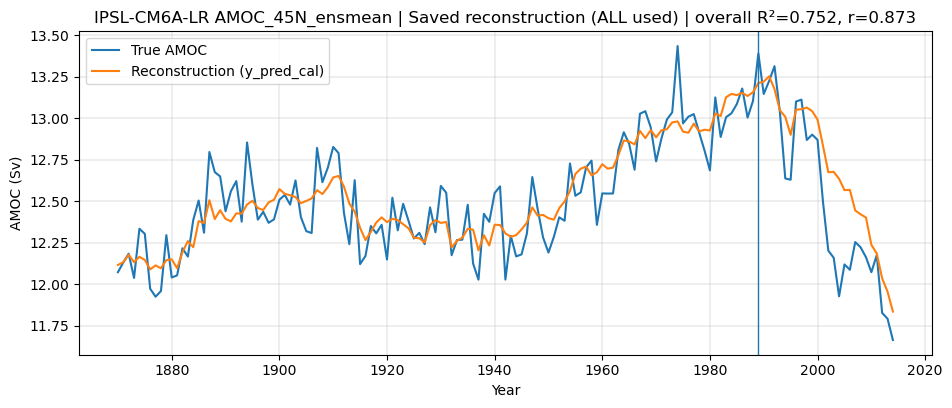

Saved reconstruction plot (ALL).

✅ Spike curve Ridge alpha = 50
✅ Saved spike curve CSV: /data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50/04_overall_r2_curve_ranked_features.csv
✅ Saved spike TXT: /data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50/04_r2_spikes_top10_OVERALL.txt


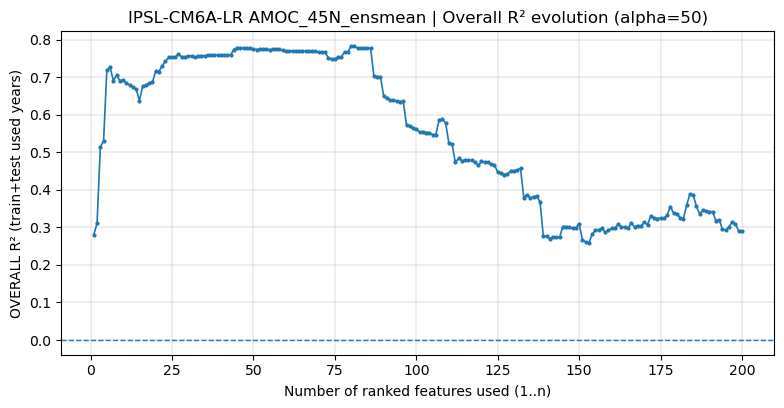

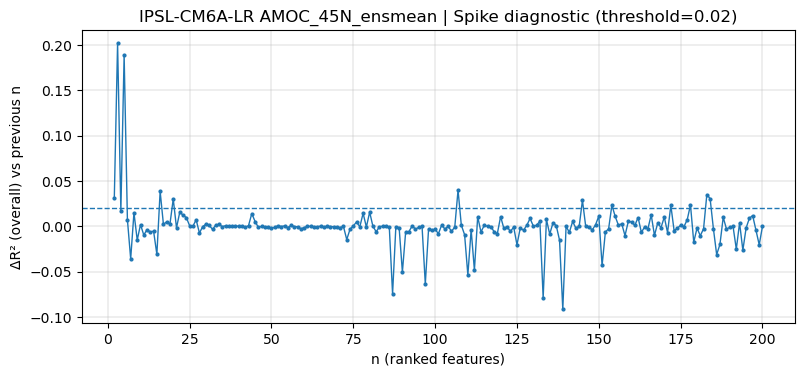

Saved spike plots.


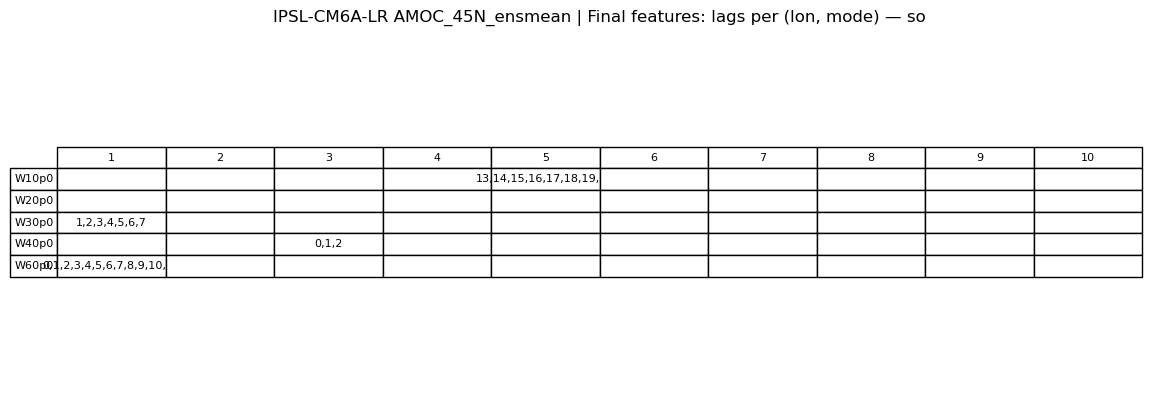

Saved feature map: so


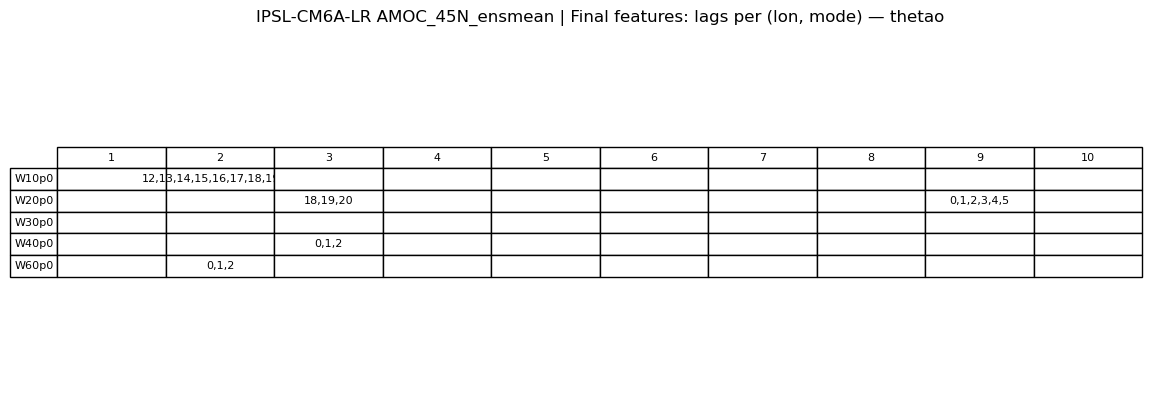

Saved feature map: thetao


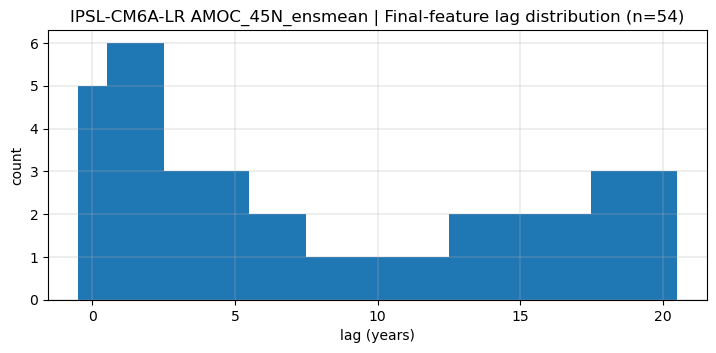

Saved lag histogram.

✅ Done. Figures + CSVs in: /data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50/


In [8]:
#!/usr/bin/env python3
"""
PLOTTING (TRAIN-ONLY EOF basis) + OVERALL SPIKE CURVE
======================================================
Uses:
  - saved pipeline outputs (SAVE_TAG files)
  - EOF netCDFs that contain TRAIN_END / train_mask
Ensures split matches EOF training window exactly (no 80/20 fraction assumptions).

This version adds:
  (A) Overall R²/corr curve as you add ranked features 1..N
  (B) Spike detection (ΔR²) + spike plot
  (C) Saves CSV + top-spike TXT

IMPORTANT:
- Uses TRAIN_END_YEAR from EOF file to define TRAIN vs TEST.
- Fits Ridge on TRAIN only (after lag-loss), predicts on ALL used years.
- Calibrates amplitude using TRAIN preds only: y ≈ a*pred + b (no leakage).
- Computes OVERALL metrics on ALL used years (train+test).

"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL   = "IPSL-CM6A-LR"
TARGET  = "AMOC_45N_ensmean"
MODE    = "ensmean"         # "ensmean" or "member"
member_id = None            # set if MODE="member"

VARS     = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES  = 10

EOF_DIR  = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# NOTE: PIPE_DIR should point to the folder that contains the SAVE_TAG_* files
PIPE_DIR = f"/data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/"
SAVE_TAG = "EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50"   # <-- your run id (folder/tag prefix)

OUTDIR = f"/data/users/frekle/AMOC_analysis/Overall_best_corr/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

# --- NEW pipeline file names (overall version) ---
BEST_FEATURES_CSV      = os.path.join(PIPE_DIR, f"{SAVE_TAG}_final_features.csv")
RANK_CSV               = os.path.join(PIPE_DIR, f"{SAVE_TAG}_trainval_feature_ranking.csv")
BEST_PARAMS_CSV        = os.path.join(PIPE_DIR, f"{SAVE_TAG}_best_params.csv")
PRED_ALL_CSV           = os.path.join(PIPE_DIR, f"{SAVE_TAG}_predictions_ALL.csv")
OVERALL_METRICS_CSV    = os.path.join(PIPE_DIR, f"{SAVE_TAG}_overall_metrics.csv")
CALIB_CSV              = os.path.join(PIPE_DIR, f"{SAVE_TAG}_calibration.csv")

print("✅ Using saved run:", SAVE_TAG)
print("✅ EOF_DIR:", EOF_DIR)
print("✅ OUTDIR:", OUTDIR)

# ----------------------------
# Helpers
# ----------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))
    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        else:
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    years = extract_years(y["time"])
    y = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    y = y.astype(float)

    if "member" in y.dims:
        if mode == "ensmean":
            y = y.mean("member")
        else:
            y = y.isel(member=int(member_id))
    ds.close()
    return y.squeeze()

def get_train_end_year_from_eof(eof_dir, var="so", lon="W30p0"):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file to infer TRAIN_END: {f}")
    ds = xr.open_dataset(f)

    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y

    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])

    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END from {f} (no attrs and no train_mask).")

def savefig(path_base, dpi=220):
    plt.savefig(path_base + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(path_base + ".pdf", dpi=dpi, bbox_inches="tight")

def corr_1d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m] - np.mean(a[m])
    b = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(a*a) * np.sum(b*b))
    if denom == 0:
        return np.nan
    return float(np.sum(a*b) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]; y_pred = y_pred[m]
    if len(y_true) < 2:
        return np.nan, np.nan
    r2 = float(r2_score(y_true, y_pred))
    r  = corr_1d(y_true, y_pred)
    return r2, r

def build_X_from_ranked_features(pc_np, years, df_rank_top):
    """
    Build X for features listed in df_rank_top (in that order).
    df_rank_top must have: var, lon, mode0, lag
    Returns:
      X_used (n_used, n_feat), Y_index_used (t indices into years), maxlag
    """
    feats = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode0"]), int(r["lag"]))
             for _, r in df_rank_top.iterrows()]
    maxlag = max([lag for (_,_,_,lag) in feats]) if feats else 0

    T = len(years)
    used_t = np.arange(maxlag, T, dtype=int)
    X = np.empty((len(used_t), len(feats)), float)

    for j, (var, lon, m0, lag) in enumerate(feats):
        X[:, j] = pc_np[(var, lon)][used_t - lag, m0]

    return X, used_t, int(maxlag), feats

# ----------------------------
# 0) Determine correct split cutoff (from EOF file)
# ----------------------------
TRAIN_END_YEAR = get_train_end_year_from_eof(EOF_DIR, var="so", lon="W30p0")
print("✅ TRAIN_END_YEAR from EOF file =", TRAIN_END_YEAR)

# ----------------------------
# 1) Load ranking + chosen features (final set)
# ----------------------------
df_rank = pd.read_csv(RANK_CSV)
if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
if "abs_corr" not in df_rank.columns and "corr" in df_rank.columns:
    df_rank["abs_corr"] = df_rank["corr"].abs()
df_rank["var"] = df_rank["var"].astype(str).str.strip()
df_rank["lon"] = df_rank["lon"].astype(str).str.strip()
df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

df_feats = pd.read_csv(BEST_FEATURES_CSV)
if "mode0" in df_feats.columns:
    feats_final = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode0"]), int(r["lag"]))
                   for _, r in df_feats.iterrows()]
else:
    feats_final = [(str(r["var"]).strip(), str(r["lon"]).strip(), int(r["mode"]) - 1, int(r["lag"]))
                   for _, r in df_feats.iterrows()]

print("Loaded final feats:", len(feats_final))
print("Loaded ranking rows:", len(df_rank))

# ----------------------------
# 2) Load AMOC + PCs (only what ranking needs)
# ----------------------------
amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set(zip(df_rank["var"], df_rank["lon"])))
pc_dict = {}
missing = []
for var, lon in needed_pairs:
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        missing.append((var, lon))
        continue
    pc_dict[(var, lon)] = load_pc_latdepth(var, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)

if missing:
    print("⚠️ Missing EOF files (ignored in spike curve):")
    for p in missing[:20]:
        print("   ", p)
    if len(missing) > 20:
        print("   ...", len(missing) - 20, "more")

# Align common years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years, int)
common_years.sort()

y = amoc.sel(year=common_years).values.astype(float)
pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}  # (T, mode)

# Split indices based on TRAIN_END_YEAR (NOTE: spike curve uses "used years" after lag-loss)
idx_train_years = np.where(common_years <= TRAIN_END_YEAR)[0]
idx_test_years  = np.where(common_years >  TRAIN_END_YEAR)[0]

print(f"✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")
print(f"✓ TRAIN:       {common_years[idx_train_years[0]]}–{common_years[idx_train_years[-1]]} (T={len(idx_train_years)})")
print(f"✓ TEST:        {common_years[idx_test_years[0]]}–{common_years[idx_test_years[-1]]} (T={len(idx_test_years)})")

# ----------------------------
# 3) Plot saved reconstruction (ALL used years) from pipeline output
# ----------------------------
if os.path.exists(PRED_ALL_CSV):
    df_pred_all = pd.read_csv(PRED_ALL_CSV)

    title_extra = ""
    if os.path.exists(OVERALL_METRICS_CSV):
        met = pd.read_csv(OVERALL_METRICS_CSV).iloc[0].to_dict()
        title_extra = (
            f" | overall R²={met.get('overall_r2', np.nan):.3f}, "
            f"r={met.get('overall_corr', np.nan):.3f}"
        )

    plt.figure(figsize=(11.0, 4.2))
    plt.plot(df_pred_all["year"], df_pred_all["y_true"], label="True AMOC")

    # prefer calibrated
    pred_col = "y_pred_cal" if "y_pred_cal" in df_pred_all.columns else (
        "y_pred" if "y_pred" in df_pred_all.columns else "y_pred_raw"
    )
    plt.plot(df_pred_all["year"], df_pred_all[pred_col], label=f"Reconstruction ({pred_col})")

    plt.axvline(TRAIN_END_YEAR, linewidth=1)
    plt.xlabel("Year")
    plt.ylabel("AMOC (Sv)")
    plt.title(f"{MODEL} {TARGET} | Saved reconstruction (ALL used){title_extra}")
    plt.grid(True, linewidth=0.3)
    plt.legend(loc="best")
    savefig(os.path.join(OUTDIR, "01_saved_reconstruction_ALL"))
    plt.show()
    print("Saved reconstruction plot (ALL).")
else:
    print("⚠️ Missing:", PRED_ALL_CSV, "(skipping saved reconstruction plot)")

# ----------------------------
# 4) SPIKE CURVE (OVERALL) from ranked features
# ----------------------------
# Get alpha from best params if possible (fallback to parse A from SAVE_TAG)
alpha = None
if os.path.exists(BEST_PARAMS_CSV):
    try:
        alpha = float(pd.read_csv(BEST_PARAMS_CSV).iloc[0]["alpha"])
    except Exception:
        alpha = None
if alpha is None:
    # crude fallback: parse "_A50" etc
    import re
    m = re.search(r"_A([0-9.]+)", SAVE_TAG)
    alpha = float(m.group(1)) if m else 50.0

print(f"\n✅ Spike curve Ridge alpha = {alpha:g}")

# Only keep ranked rows whose (var,lon) PC exists
ok_mask = [( (r["var"], r["lon"]) in pc_np ) for _, r in df_rank.iterrows()]
df_rank_ok = df_rank.loc[ok_mask].reset_index(drop=True)
if len(df_rank_ok) < 5:
    raise RuntimeError("Too few ranked rows have available PCs after filtering missing EOF files.")

# How many ranked features to test in the curve
R2_CURVE_MAX = min(200, len(df_rank_ok))   # change if you want (e.g., 500)
SPIKE_D_R2_MIN = 0.02                      # your spike threshold

rows = []
prev_r2 = np.nan

for n in range(1, R2_CURVE_MAX + 1):
    df_top = df_rank_ok.head(n).copy()

    # Build lag-safe X for these n features
    X, used_t, maxlag, feats_n = build_X_from_ranked_features(pc_np, common_years, df_top)
    Y = y[used_t]
    years_used = common_years[used_t]

    # TRAIN/TEST split in used-space (by year cutoff)
    idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
    idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]
    if len(idx_tr) < 20 or len(idx_te) < 10:
        # still record, but likely unstable
        pass

    # Fit on TRAIN only
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(X[idx_tr, :], Y[idx_tr])

    # Predict on ALL used years
    pred_all_raw = mdl.predict(X)

    # Calibrate amplitude on TRAIN only: y ≈ a*pred + b
    a_cal, b_cal = np.polyfit(pred_all_raw[idx_tr], Y[idx_tr], 1)
    pred_all_cal = a_cal * pred_all_raw + b_cal

    overall_r2, overall_r = metrics(Y, pred_all_cal)

    d_r2 = np.nan
    if np.isfinite(prev_r2) and np.isfinite(overall_r2):
        d_r2 = overall_r2 - prev_r2
    prev_r2 = overall_r2

    rows.append({
        "n_features": n,
        "maxlag_used": int(maxlag),
        "overall_r2": float(overall_r2),
        "overall_corr": float(overall_r),
        "delta_r2": float(d_r2) if np.isfinite(d_r2) else np.nan,
        "calib_a": float(a_cal),
        "calib_b": float(b_cal),
        "n_train_used": int(len(idx_tr)),
        "n_test_used": int(len(idx_te)),
        "last_added_feature": f"{feats_n[-1][0]} {feats_n[-1][1]} EOF{feats_n[-1][2]+1} lag{feats_n[-1][3]}",
    })

df_curve = pd.DataFrame(rows)

curve_csv = os.path.join(OUTDIR, "04_overall_r2_curve_ranked_features.csv")
df_curve.to_csv(curve_csv, index=False)
print("✅ Saved spike curve CSV:", curve_csv)

# Identify spikes
df_spikes = df_curve.copy()
df_spikes = df_spikes[np.isfinite(df_spikes["delta_r2"])].copy()
df_spikes = df_spikes[df_spikes["delta_r2"] >= float(SPIKE_D_R2_MIN)].copy()
df_spikes = df_spikes.sort_values("delta_r2", ascending=False).head(10)

spike_txt = os.path.join(OUTDIR, "04_r2_spikes_top10_OVERALL.txt")
with open(spike_txt, "w") as f:
    f.write(f"Top spikes (ΔR² >= {SPIKE_D_R2_MIN}) — OVERALL metric\n")
    f.write(f"ranked curve length = {R2_CURVE_MAX}\n\n")
    if len(df_spikes) == 0:
        f.write("No spikes found.\n")
    else:
        for _, r in df_spikes.iterrows():
            f.write(f"n={int(r['n_features']):3d}  ΔR²={r['delta_r2']:.3f}  R²={r['overall_r2']:.3f}  | {r['last_added_feature']}\n")
print("✅ Saved spike TXT:", spike_txt)

# Plot curve + spikes
plt.figure(figsize=(9.2, 4.2))
plt.plot(df_curve["n_features"], df_curve["overall_r2"], marker="o", markersize=2, linewidth=1.2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Number of ranked features used (1..n)")
plt.ylabel("OVERALL R² (train+test used years)")
plt.title(f"{MODEL} {TARGET} | Overall R² evolution (alpha={alpha:g})")
plt.grid(True, linewidth=0.3)
savefig(os.path.join(OUTDIR, "04_overall_r2_curve"))
plt.show()

plt.figure(figsize=(9.2, 3.8))
plt.plot(df_curve["n_features"], df_curve["delta_r2"], marker="o", markersize=2, linewidth=1.0)
plt.axhline(float(SPIKE_D_R2_MIN), linestyle="--", linewidth=1)
plt.xlabel("n (ranked features)")
plt.ylabel("ΔR² (overall) vs previous n")
plt.title(f"{MODEL} {TARGET} | Spike diagnostic (threshold={SPIKE_D_R2_MIN})")
plt.grid(True, linewidth=0.3)
savefig(os.path.join(OUTDIR, "04_overall_r2_spikes"))
plt.show()

print("Saved spike plots.")

# ----------------------------
# 5) Feature map (simple): for final selected features only
# ----------------------------
dfF = pd.DataFrame([{"var":v,"lon":lon,"mode":m0+1,"lag":lag} for (v,lon,m0,lag) in feats_final])
dfF["lag"] = dfF["lag"].astype(int)

for var in sorted(dfF["var"].unique()):
    g = (dfF[dfF["var"]==var]
         .groupby(["lon","mode"])["lag"]
         .apply(lambda s: ",".join(map(str, sorted(set(s)))))
         .reset_index(name="lags"))

    lons  = LON_TAGS
    modes = list(range(1, N_MODES+1))

    cell = np.full((len(lons), len(modes)), "", dtype=object)
    for _, r in g.iterrows():
        if r["lon"] in lons and int(r["mode"]) in modes:
            i = lons.index(r["lon"])
            j = modes.index(int(r["mode"]))
            cell[i, j] = r["lags"]

    fig, ax = plt.subplots(figsize=(1.1*len(modes)+3, 0.5*len(lons)+2))
    ax.axis("off")
    tbl = ax.table(
        cellText=cell,
        rowLabels=lons,
        colLabels=[str(m) for m in modes],
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.3)

    ax.set_title(f"{MODEL} {TARGET} | Final features: lags per (lon, mode) — {var}", pad=12)
    savefig(os.path.join(OUTDIR, f"05_feature_map_final_{var}"))
    plt.show()
    print("Saved feature map:", var)

# ----------------------------
# 6) Lag histogram (final features)
# ----------------------------
plt.figure(figsize=(8.5, 3.5))
lags = dfF["lag"].values
bins = np.arange(lags.min(), lags.max()+2) - 0.5
plt.hist(lags, bins=bins)
plt.xlabel("lag (years)")
plt.ylabel("count")
plt.title(f"{MODEL} {TARGET} | Final-feature lag distribution (n={len(dfF)})")
plt.grid(True, linewidth=0.3)
savefig(os.path.join(OUTDIR, "06_lag_hist_final"))
plt.show()
print("Saved lag histogram.")

print("\n✅ Done. Figures + CSVs in:", OUTDIR)

In [10]:
#!/usr/bin/env python3
"""
SPIKE-FEATURE SUBSET SEARCH (TRAIN-ONLY EOF basis) — UPDATED FOR NEW FILES
==========================================================================
Goal:
  Given
    - a ranking CSV (ordered list of features)
    - a spikes TXT (spike positions n = number of features in incremental curve),
  find which COMBINATIONS of the spike features give the highest skill.

What's new vs your old script
-----------------------------
✅ Works with BOTH old + new file conventions:
  - ranking CSV can have: (mode) 1-based OR (mode0) 0-based
  - lon column name can be: lon OR lon_tag
  - spikes txt can be:
      "n=  5  ΔR²=0.414  R²=0.756"
    OR
      "... | so W60p0 EOF1 lag1" (your new OVERALL spike txt)

✅ Scores BOTH:
  - TEST-only metrics (years > TRAIN_END_YEAR)
  - OVERALL metrics on ALL used years (train+test) [no leakage: calibration fit on TRAIN only]

✅ Objective is configurable:
  - choose best subsets by TEST R² (default) or OVERALL R² or corr.

Fair comparison design (same as before)
---------------------------------------
We evaluate ALL subsets on the SAME years by using:
  GLOBAL_MAXLAG = max lag among candidate spike features
so train/test windows are identical across all subsets.

Outputs
-------
  - best_subsets_by_k.csv
  - (optional) all_subsets_scored.csv
  - summary_best_subsets.txt
"""

import os
import re
import itertools
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Prevent HDF5 file locking issues on shared filesystems
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"        # "ensmean" or "member"
member_id = None          # if MODE="member", set label/index

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Inputs
RANK_CSV   = "/data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/mode_ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50_trainval_feature_ranking.csv"
SPIKES_TXT = "/data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/EOFtrain_TRAINONLY/EOFTRAINONLY_Ynone_PCnone_R2_0.752_N30_W2_A50/04_r2_spikes_top10_OVERALL.txt"

# Output folder
OUTDIR = f"/data/users/frekle/AMOC_analysis/Overall_best_corr/{MODEL}/{TARGET}/{MODE}/SPIKE_SUBSET_SEARCH/"
os.makedirs(OUTDIR, exist_ok=True)

# PC setup
N_MODES = 10

# Ridge alpha (you can parse from tag, or just set it)
ALPHA = 50

# Optional detrending (TRAIN-fit, no leakage)
DETREND_Y = True
DETREND_X = True

# Subset search settings
MAX_FEATURES_TO_USE = 10         # evaluate best subset size 1..10 (or up to number of candidates)
SAVE_ALL_SUBSETS = True          # WARNING: can be large if many candidates

# What to optimize for ("test_r2", "overall_r2", "test_corr", "overall_corr")
OBJECTIVE = "test_r2"

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    if "PC" not in ds:
        raise KeyError(f"'PC' not found in {f}. Variables: {list(ds.data_vars)}")

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    if "year" in y.dims:
        am = y
        if "time" in am.coords:
            am = am.drop_vars("time")
    else:
        years = extract_years(y["time"])
        am = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am = am.astype(float)

    if "member" in am.dims:
        if mode == "ensmean":
            am = am.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return am.squeeze()

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    all_years = np.asarray(all_years, float)
    all_series = np.asarray(all_series, float)
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_spike_ns(path_txt):
    """
    Robustly parse spike positions from BOTH old + new txt formats.

    Old format line example:
      n=  5  ΔR²=0.414  R²=0.756

    New format line example:
      n= 44  ΔR²=0.041  R²=0.790  | so W60p0 EOF1 lag1
    """
    ns = []
    with open(path_txt, "r") as f:
        for line in f:
            m = re.search(r"\bn=\s*(\d+)\b", line)
            if m:
                ns.append(int(m.group(1)))
    ns = sorted(set(ns))
    if not ns:
        raise ValueError(f"No spike 'n=' entries found in {path_txt}")
    return ns

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def load_ranked_features(csv_path):
    """
    Accepts ranking CSVs that may have:
      - mode (1-based) OR mode0 (0-based)
      - lon OR lon_tag
    Returns:
      feats_ranked: list[(var, lon, mode0, lag)] in CSV order
      df: dataframe with standardized columns var, lon, mode0, lag
    """
    df = pd.read_csv(csv_path)

    var_col  = _find_col(df, ["var", "variable"])
    lon_col  = _find_col(df, ["lon", "lon_tag", "longitude_tag"])
    lag_col  = _find_col(df, ["lag", "LAG"])
    mode0_col = _find_col(df, ["mode0"])
    mode1_col = _find_col(df, ["mode", "Mode"])

    if var_col is None or lon_col is None or lag_col is None or (mode0_col is None and mode1_col is None):
        raise KeyError(
            f"Ranking CSV missing required columns. "
            f"Need var, lon, lag, and (mode0 or mode). "
            f"Found columns: {list(df.columns)}"
        )

    out = pd.DataFrame()
    out["var"] = df[var_col].astype(str).str.strip()
    out["lon"] = df[lon_col].astype(str).str.strip()
    out["lag"] = df[lag_col].astype(int)

    if mode0_col is not None:
        out["mode0"] = df[mode0_col].astype(int)
    else:
        out["mode0"] = df[mode1_col].astype(int) - 1

    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in out.iterrows()]
    return feats, out

# ------------------------------------------------------------
# 1) Build spike-feature candidate list
# ------------------------------------------------------------
feats_ranked, df_rank_std = load_ranked_features(RANK_CSV)
spike_ns = parse_spike_ns(SPIKES_TXT)

cands = []
for n in spike_ns:
    if 1 <= n <= len(feats_ranked):
        cands.append(feats_ranked[n - 1])
    else:
        print(f"⚠️ spike n={n} outside ranking length={len(feats_ranked)} -> skipped")

# De-duplicate while preserving order
seen = set()
cand_feats = []
for ft in cands:
    if ft not in seen:
        cand_feats.append(ft)
        seen.add(ft)

M = len(cand_feats)
if M == 0:
    raise RuntimeError("No candidate spike features found after parsing.")

print("\n==============================")
print("SPIKE CANDIDATE FEATURES")
print("==============================")
print(f"Spike ns parsed: {spike_ns}")
print(f"Candidate spike features (unique): {M}")
for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
    print(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}")

KMAX = min(int(MAX_FEATURES_TO_USE), M)

# ------------------------------------------------------------
# 2) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so", "W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in cand_feats))
pc_dict = {}
for (v, lon) in needed_pairs:
    pc_dict[(v, lon)] = load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 3) Fix the evaluation window (GLOBAL_MAXLAG) for fair comparison
# ------------------------------------------------------------
GLOBAL_MAXLAG = max(lag for *_, lag in cand_feats)
used_global = np.arange(GLOBAL_MAXLAG, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

print("\nSplit on years_used (fixed by GLOBAL_MAXLAG):")
print("GLOBAL_MAXLAG:", GLOBAL_MAXLAG)
print("Train:", years_used[idx_tr[0]], "–", years_used[idx_tr[-1]], "n=", len(idx_tr))
print("Test :", years_used[idx_te[0]], "–", years_used[idx_te[-1]], "n=", len(idx_te))

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y using TRAIN-only fit
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

# Build candidate design matrix (T_used, M)
X_cand = np.empty((len(used_global), M), dtype=float)
for j, (var, lon, m0, lag) in enumerate(cand_feats):
    X_cand[:, j] = pc_np[(var, lon)][used_global - lag, m0]

# Detrend X columns (TRAIN-only fit)
if DETREND_X:
    X_cand_dt = X_cand.copy()
    for j in range(M):
        X_cand_dt[:, j], _ = detrend_with_train_fit(years_used, X_cand[:, j], train_mask_used)
else:
    X_cand_dt = X_cand

# ------------------------------------------------------------
# 4) Exhaustive subset search (sizes 1..KMAX)
# ------------------------------------------------------------
def score_subset(Xk, Y, idx_tr, idx_te, alpha):
    """Fit on TRAIN, calibrate on TRAIN preds only, return test+overall metrics (calibrated)."""
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(Xk[idx_tr], Y[idx_tr])

    pred_all_raw = mdl.predict(Xk)

    # amplitude calibration on TRAIN only (no leakage)
    a_cal, b_cal = np.polyfit(pred_all_raw[idx_tr], Y[idx_tr], 1)
    pred_all_cal = a_cal * pred_all_raw + b_cal

    # metrics
    test_r2 = float(r2_score(Y[idx_te], pred_all_cal[idx_te]))
    test_corr = pearson_corr(Y[idx_te], pred_all_cal[idx_te])

    overall_r2 = float(r2_score(Y, pred_all_cal))
    overall_corr = pearson_corr(Y, pred_all_cal)

    return dict(
        test_r2=test_r2, test_corr=test_corr,
        overall_r2=overall_r2, overall_corr=overall_corr,
        calib_a=float(a_cal), calib_b=float(b_cal)
    )

def subset_str_from_idx(subset_idx):
    subset_feats = [cand_feats[i] for i in subset_idx]
    return " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in subset_feats])

def objective_value(sc, obj):
    if obj not in sc:
        raise KeyError(f"OBJECTIVE='{obj}' not in score dict keys: {list(sc.keys())}")
    return sc[obj]

all_rows = []
best_by_k = []

print("\n==============================")
print("SUBSET SEARCH")
print("==============================")
print("Objective:", OBJECTIVE)
print("Candidates:", M, "| Evaluating k=1..", KMAX)

for k in range(1, KMAX + 1):
    best = None
    best_val = -np.inf

    for subset_idx in itertools.combinations(range(M), k):
        subset_idx = tuple(subset_idx)
        Xk = X_cand_dt[:, subset_idx]

        sc = score_subset(Xk, Y_dt, idx_tr, idx_te, ALPHA)
        val = objective_value(sc, OBJECTIVE)

        if SAVE_ALL_SUBSETS:
            row = dict(k=k,
                       subset_idx=",".join(map(str, subset_idx)),
                       subset_features=subset_str_from_idx(subset_idx))
            row.update(sc)
            all_rows.append(row)

        if np.isfinite(val) and val > best_val:
            best_val = val
            best = (subset_idx, sc)

    if best is None:
        print(f"⚠️ k={k}: no valid subsets scored")
        continue

    subset_idx, sc = best
    best_by_k.append(dict(
        k=k,
        subset_idx=",".join(map(str, subset_idx)),
        subset_features=subset_str_from_idx(subset_idx),
        **sc
    ))

    print(f"\nBEST k={k}: "
          f"test R²={sc['test_r2']:.4f} r={sc['test_corr']:.4f} | "
          f"overall R²={sc['overall_r2']:.4f} r={sc['overall_corr']:.4f} | "
          f"calib a={sc['calib_a']:.3f} b={sc['calib_b']:.3f}")
    for (v, lon, m0, lag) in [cand_feats[i] for i in subset_idx]:
        print(f"  - {v:6s} {lon:6s} EOF{m0+1:<2d} lag{lag}")

# ------------------------------------------------------------
# 5) Save results
# ------------------------------------------------------------
best_df = pd.DataFrame(best_by_k)
best_csv = os.path.join(OUTDIR, "best_subsets_by_k.csv")
best_df.to_csv(best_csv, index=False)
print("\n✅ Saved best subsets by k:", best_csv)

if SAVE_ALL_SUBSETS:
    all_df = pd.DataFrame(all_rows)
    # sort by objective within each k
    all_df["_obj"] = all_df[OBJECTIVE]
    all_df = all_df.sort_values(["k", "_obj"], ascending=[True, False]).drop(columns=["_obj"]).reset_index(drop=True)
    all_csv = os.path.join(OUTDIR, "all_subsets_scored.csv")
    all_df.to_csv(all_csv, index=False)
    print("✅ Saved all subset scores:", all_csv)

summary_txt = os.path.join(OUTDIR, "summary_best_subsets.txt")
with open(summary_txt, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\nGLOBAL_MAXLAG={GLOBAL_MAXLAG}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"OBJECTIVE={OBJECTIVE}\n")
    f.write("\nCandidate features:\n")
    for i, (v, lon, m0, lag) in enumerate(cand_feats, 1):
        f.write(f"  C{i}: {v} {lon} EOF{m0+1} lag{lag}\n")
    f.write("\nBest subsets by k:\n")
    for row in best_by_k:
        f.write(f"\nK={row['k']}\n")
        f.write(f"  test_r2={row['test_r2']:.6f}  test_corr={row['test_corr']:.6f}\n")
        f.write(f"  overall_r2={row['overall_r2']:.6f}  overall_corr={row['overall_corr']:.6f}\n")
        f.write(f"  calib_a={row['calib_a']:.6f}  calib_b={row['calib_b']:.6f}\n")
        f.write("  " + row["subset_features"] + "\n")
print("✅ Saved summary:", summary_txt)

print("\nDONE.")


SPIKE CANDIDATE FEATURES
Spike ns parsed: [2, 3, 5, 16, 20, 107, 145, 178, 183, 184]
Candidate spike features (unique): 10
  C1: so W60p0 EOF1 lag2
  C2: so W60p0 EOF1 lag8
  C3: thetao W10p0 EOF2 lag16
  C4: thetao W60p0 EOF2 lag0
  C5: so W60p0 EOF1 lag0
  C6: so W30p0 EOF9 lag12
  C7: thetao W20p0 EOF9 lag6
  C8: thetao W60p0 EOF6 lag15
  C9: so W10p0 EOF8 lag18
  C10: so W10p0 EOF8 lag19

✅ TRAIN_END_YEAR inferred from EOF files: 1989

Split on years_used (fixed by GLOBAL_MAXLAG):
GLOBAL_MAXLAG: 19
Train: 1869 – 1989 n= 121
Test : 1990 – 2014 n= 25
✅ Detrended Y using TRAIN fit: y_trend = 5.9314e-03*year + 1.0814e+00

SUBSET SEARCH
Objective: test_r2
Candidates: 10 | Evaluating k=1.. 10

BEST k=1: test R²=0.7421 r=0.8924 | overall R²=0.6190 r=0.7884 | calib a=1.413 b=-0.000
  - thetao W60p0  EOF2  lag0

BEST k=2: test R²=0.8394 r=0.9327 | overall R²=0.6906 r=0.8347 | calib a=1.324 b=-0.000
  - so     W60p0  EOF1  lag0
  - thetao W20p0  EOF9  lag6

BEST k=3: test R²=0.8386 r=0.9310


CHOSEN SUBSET
  F1: so W60p0 EOF1 lag2
  F2: so W60p0 EOF1 lag0
  F3: thetao W20p0 EOF9 lag6
  F4: thetao W60p0 EOF6 lag15

✅ TRAIN_END_YEAR inferred from EOF files: 1989
✅ Detrended Y using TRAIN fit: y_trend = 5.8061e-03*year + 1.3255e+00

MODEL SKILL (detrended space if enabled)
Train R²=0.3978  corr=0.6394
Test  R²=0.8408  corr=0.9318


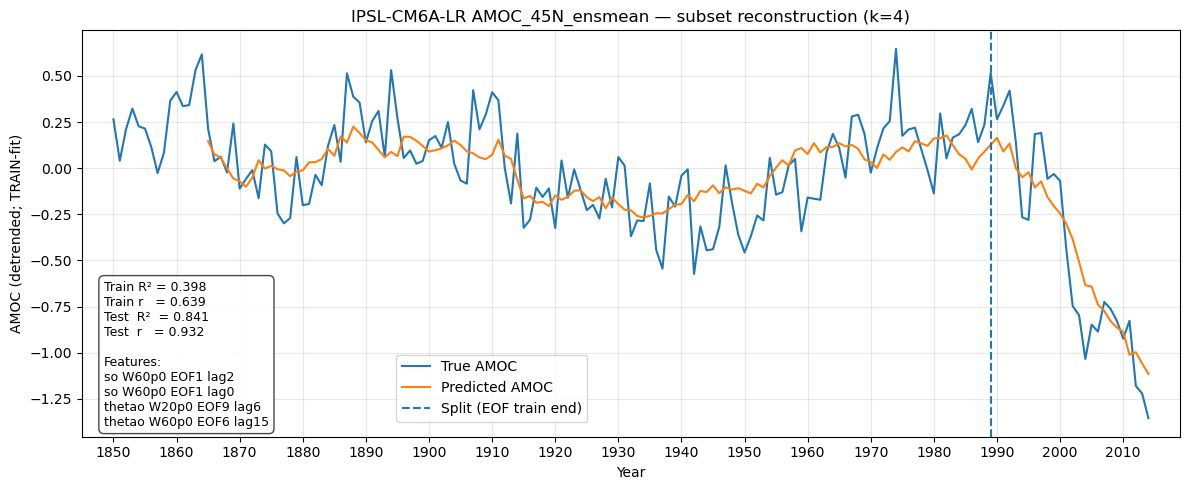

✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/PLOT_SUBSET/01_reconstruction_k4.png/.pdf
[EOF MAP] so W60p0 EOF1: depth range = 0.5 .. 4888.1
[EOF MAP] thetao W20p0 EOF9: depth range = 0.5 .. 4888.1
[EOF MAP] thetao W60p0 EOF6: depth range = 0.5 .. 4888.1


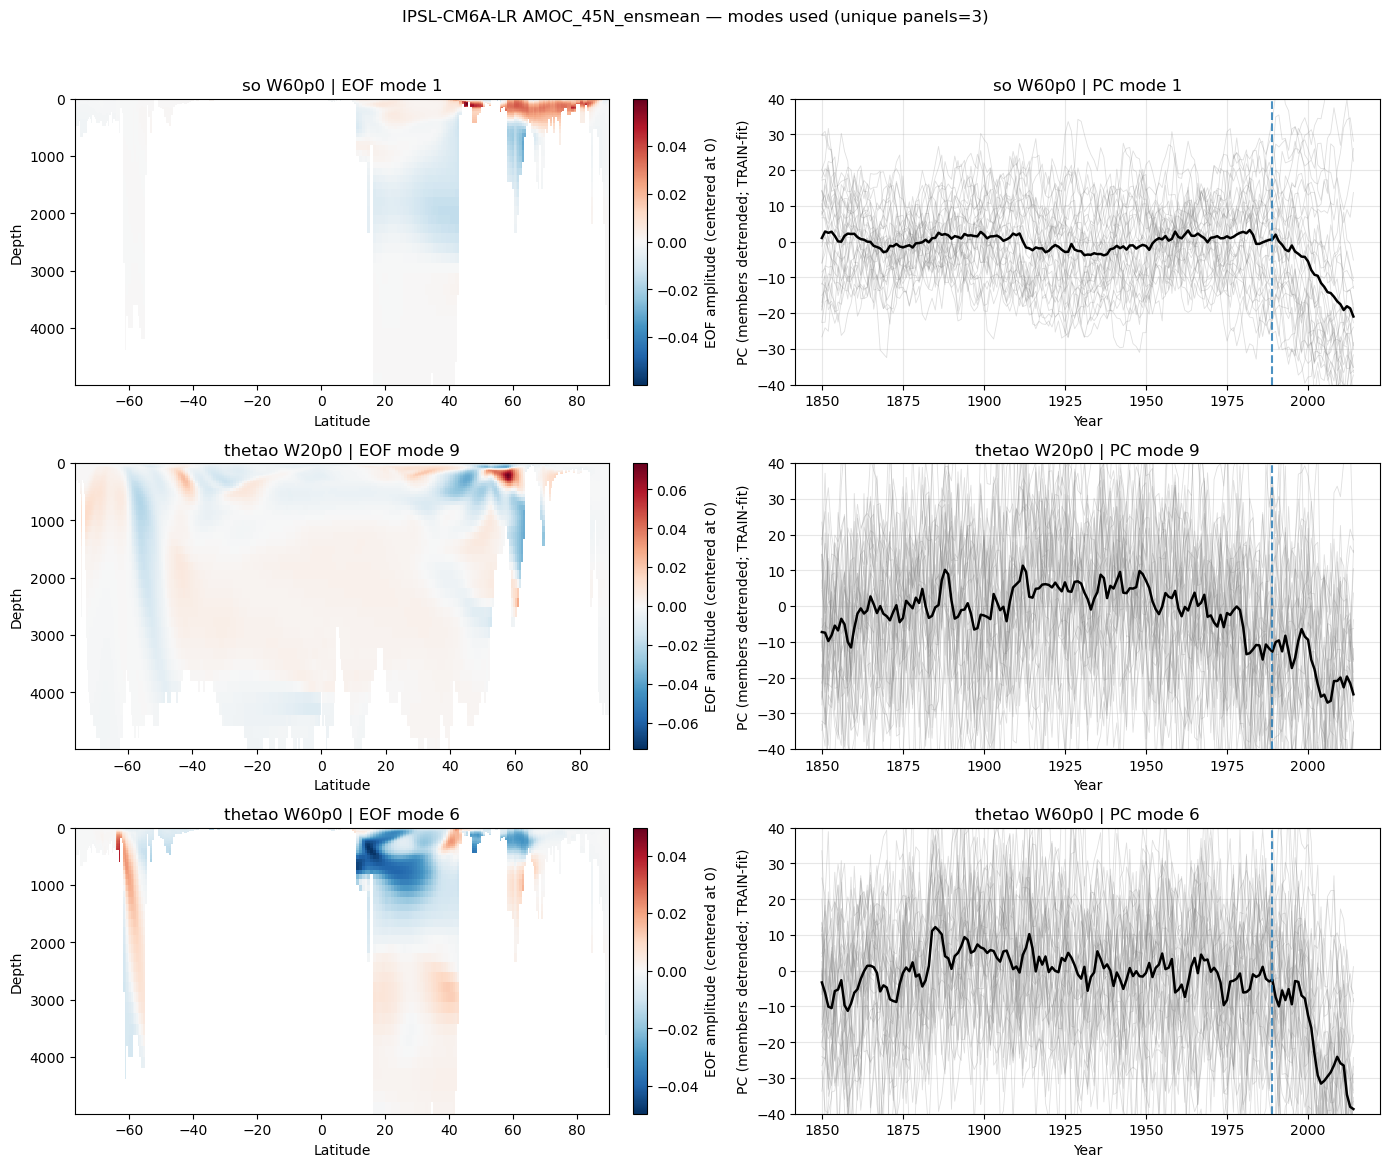

✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/PLOT_SUBSET/02_EOFmap_and_PC_k4.png/.pdf


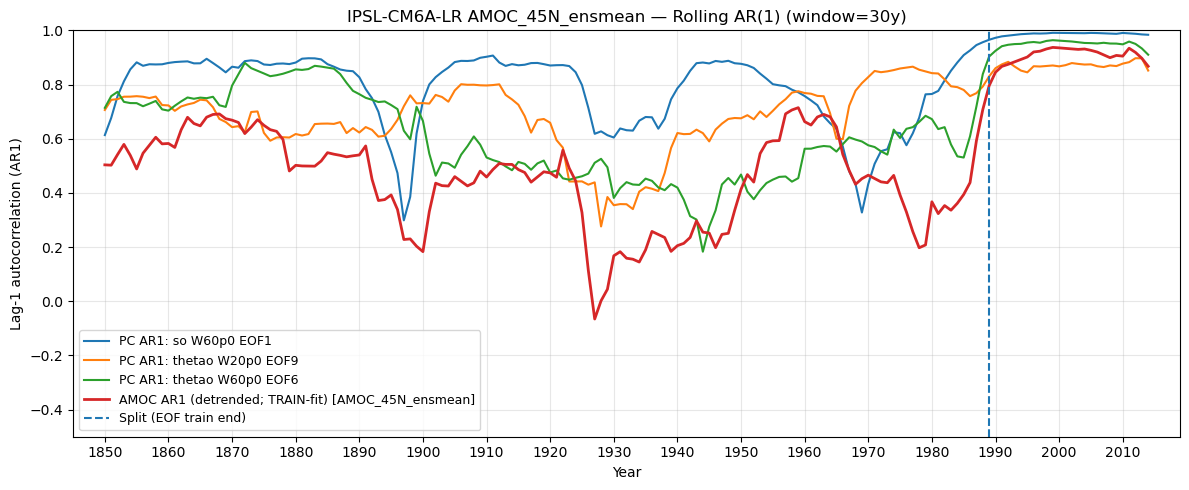

✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/PLOT_SUBSET/03_AR1_PC_plus_AMOC_k4_W30.png/.pdf
✅ Saved: /data/users/frekle/AMOC_analysis/THESIS_FIGURES/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/PLOT_SUBSET/meta_k4.txt

DONE.


In [5]:
#!/usr/bin/env python3
"""
PLOT A CHOSEN SUBSET (TRAIN-ONLY EOF basis) — FIXED SPATIAL MAP
==============================================================
This version uses the SAME lat–depth EOF-map logic as your working
RUN-ALL FIGURES PIPELINE (imshow with extent, EOFm.transpose(depth,lat)).

Produces 3 figures:
  (1) Reconstruction curve (true vs predicted; split shown)
  (2) For each unique mode used: spatial EOF map + its PC curve (side-by-side)
  (3) Rolling lag-1 autocorrelation (AR1) of that PC mode

Choose subset by:
  A) manual FEATURES = [(var, lon, mode0, lag), ...]  (mode0 is 0-based)
  B) best_subsets_by_k.csv row (k=CHOOSE_K) from subset-search

Author note:
- EOF basis TRAIN-only; PCs are projected for full period (as stored in your EOF files)
- AR1 is computed on the PC of each unique (var, lon, mode0) used in the subset
"""

import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as mcolors

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"
MODE   = "ensmean"      # "ensmean" or "member"
member_id = None        # set if MODE="member" (int index or member label)

# IMPORTANT: this should point to your TRAIN-only EOF directory (same as reconstruction)
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/Train_period_85pct/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/PLOT_SUBSET/"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Choose subset source ----
SUBSET_SOURCE = "best_csv"   # "manual" or "best_csv"

# A) manual subset (mode0 is 0-based, i.e. EOF1 -> 0)
FEATURES = [
    # ("so", "W60p0", 0, 1),
    # ("thetao", "W10p0", 1, 16),
]

# B) from subset-search output CSV
BEST_CSV  = f"/data/users/frekle/AMOC_analysis/Overall_best_corr/IPSL-CM6A-LR/AMOC_45N_ensmean/ensmean/SPIKE_SUBSET_SEARCH/best_subsets_by_k.csv"
CHOOSE_K  = 4  # pick which k-subset to plot

# Ridge / preprocessing (match your reconstruction choices)
ALPHA = 50
DETREND_Y = True
DETREND_X = True

# PC setup
N_MODES = 10

# AR(1) settings
AR1_WINDOW_YEARS = 30
AR1_MIN_VALID = 10

# Plot limits
MAX_PANELS = 8   # max unique (var,lon,mode) panels in figure 2

# ------------------------------------------------------------
# UTILITIES (copied/adapted from your working pipeline)
# ------------------------------------------------------------
def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_latdepth(var, lon_tag, n_modes, eof_dir, mode="ensmean", member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if mode == "ensmean":
            PC = PC.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    ds.close()
    return PC.astype(float)  # (year, mode)

def format_year_axis(ax, years_arr, step=10, pad=5):
    years_arr = np.asarray(years_arr, int)
    ax.set_xlim(int(years_arr.min()) - pad,
                int(years_arr.max()) + pad)
    ax.xaxis.set_major_locator(MultipleLocator(step))

def load_eof_map_latdepth(var, lon_tag, eof_dir, mode_index_1based):
    """
    Returns:
      Z     : 2D array (depth, lat_like)
      depth : 1D depth coordinate (same units as file; usually meters)
      lat   : 1D lat coordinate (true lat if available else index)
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    # ---- find EOF variable name ----
    eof_var_candidates = ["EOF", "eof", "patterns", "EOFs"]
    eof_name = next((c for c in eof_var_candidates if c in ds.data_vars), None)
    if eof_name is None:
        raise KeyError(f"Could not find EOF variable in {f}. Tried {eof_var_candidates}. "
                       f"Available data_vars={list(ds.data_vars)}")

    EOF = ds[eof_name]

    # ---- select mode ----
    m0 = int(mode_index_1based) - 1
    if "mode" not in EOF.dims:
        raise KeyError(f"EOF variable has no 'mode' dim. dims={EOF.dims}")
    EOFm = EOF.isel(mode=m0)

    # ---- detect depth dim ----
    depth_dim_candidates = ["depth", "lev", "z", "olevel"]
    depth_dim = next((d for d in depth_dim_candidates if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dimension in EOF. dims={EOFm.dims}")

    # ---- detect latitude-like dim ----
    lat_dim_candidates = ["lat", "latitude", "lat_index", "y", "j"]
    lat_dim = next((d for d in lat_dim_candidates if d in EOFm.dims), None)
    if lat_dim is None:
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect latitude-like dimension. dims={EOFm.dims}")
        lat_dim = others[0]

    # ---- reorder to (depth, lat_like) ----
    EOFm = EOFm.transpose(depth_dim, lat_dim)

    # ---- coords ----
    depth = EOFm[depth_dim].values.astype(float)

    # latitude coordinate: prefer a coordinate attached to lat_dim
    lat = None
    if lat_dim in EOFm.coords:
        lat = EOFm[lat_dim].values
    # if that is just an index, try to find a true 'lat' coord with same dim
    if lat is None or (np.issubdtype(np.asarray(lat).dtype, np.integer) and "lat" in ds.coords):
        if "lat" in ds.coords and lat_dim in ds["lat"].dims:
            lat = ds["lat"].values
        elif "latitude" in ds.coords and lat_dim in ds["latitude"].dims:
            lat = ds["latitude"].values
    if lat is None:
        lat = np.arange(EOFm.sizes[lat_dim])

    Z = EOFm.values.astype(float)

    ds.close()
    return Z, depth, lat

def load_amoc(target, amoc_file, mode="ensmean", member_id=None):
    ds = xr.open_dataset(amoc_file)
    y = ds[target].squeeze()

    # handle both time/year coords robustly
    if "year" in y.dims:
        yy = y
    else:
        years = extract_years(y["time"])
        yy = y.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    yy = yy.astype(float)

    if "member" in yy.dims:
        if mode == "ensmean":
            yy = yy.mean("member")
        elif mode == "member":
            if member_id is None:
                raise ValueError("member_id must be provided when mode='member'")
            if "member" in yy.coords and member_id in yy["member"].values:
                yy = yy.sel(member=member_id)
            else:
                yy = yy.isel(member=int(member_id))
        else:
            raise ValueError("mode must be 'ensmean' or 'member'")

    ds.close()
    return yy.squeeze()  # (year,)

def load_pc_latdepth_with_members(var, lon_tag, n_modes, eof_dir):
    """
    Returns:
      PCm: xarray DataArray with dims:
           - if file has members: (year, member, mode)
           - else:               (year, mode)
    NOTE: no averaging is applied here.
    """
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    PC = ds["PC"].isel(mode=slice(0, int(n_modes)))

    # ensure year coordinate exists
    PC = PC.transpose("time", ...)

    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    ds.close()
    return PC.astype(float)

def infer_train_end_year_from_any_eof(eof_dir, prefer=("so", "W30p0")):
    var, lon = prefer
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon}.nc")
    if not os.path.exists(f):
        import glob
        hits = sorted(glob.glob(os.path.join(eof_dir, "EOF_latdepth_*_*.nc")))
        if not hits:
            raise FileNotFoundError(f"No EOF files found in {eof_dir}")
        f = hits[0]

    ds = xr.open_dataset(f)
    if "TRAIN_END" in ds.attrs:
        y = int(str(ds.attrs["TRAIN_END"])[:4])
        ds.close()
        return y
    if "train_mask" in ds:
        tm = ds["train_mask"].values.astype(bool)
        if tm.any():
            t_last = ds["time"].values[np.where(tm)[0][-1]]
            ds.close()
            return int(str(np.datetime64(t_last))[:4])
    ds.close()
    raise RuntimeError(f"Could not infer TRAIN_END year from {f}")

def fit_linear_trend(train_years, train_series):
    x = np.asarray(train_years, float)
    y = np.asarray(train_series, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return 0.0, float(np.nanmean(y))
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(a), float(b)

def detrend_with_train_fit(all_years, all_series, train_mask):
    a, b = fit_linear_trend(all_years[train_mask], all_series[train_mask])
    trend = a * all_years + b
    return all_series - trend, (a, b)

def pearson_corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return np.nan
    a = a[m]; b = b[m]
    sa = a.std(); sb = b.std()
    if sa == 0 or sb == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def parse_features_string(s):
    feats = []
    for part in str(s).split("|"):
        part = part.strip()
        m = re.search(r"(\w+)\s+(W\d+p\d+)\s+EOF(\d+)\s+lag(\d+)", part)
        if not m:
            continue
        var, lon, eofk, lag = m.group(1), m.group(2), int(m.group(3)), int(m.group(4))
        feats.append((var, lon, eofk - 1, lag))
    if not feats:
        raise ValueError(f"Could not parse any features from: {s}")
    # deduplicate preserve order
    out, seen = [], set()
    for ft in feats:
        if ft not in seen:
            out.append(ft); seen.add(ft)
    return out

def rolling_ar1(x, years, window=30, min_valid=10):
    """
    Rolling lag-1 autocorrelation: corr(x[t], x[t-1]) within a rolling window.
    """
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    n = len(x)
    if n < window:
        window = max(5, n // 2)

    ar1_vals = np.full(n, np.nan, float)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        seg = x[lo:hi]
        m = np.isfinite(seg)
        seg = seg[m]
        if len(seg) < max(min_valid, 3):
            continue
        a = seg[1:]
        b = seg[:-1]
        if len(a) < 2:
            continue
        ar1_vals[i] = pearson_corr(a, b)

    return years, ar1_vals

# ------------------------------------------------------------
# 0) Select features
# ------------------------------------------------------------
if SUBSET_SOURCE == "manual":
    feats = FEATURES
elif SUBSET_SOURCE == "best_csv":
    dfb = pd.read_csv(BEST_CSV)
    row = dfb.loc[dfb["k"] == CHOOSE_K]
    if len(row) != 1:
        raise ValueError(f"Could not uniquely find k={CHOOSE_K} in {BEST_CSV}. Available ks: {sorted(dfb['k'].unique())}")
    feats = parse_features_string(row.iloc[0]["subset_features"])
else:
    raise ValueError("SUBSET_SOURCE must be 'manual' or 'best_csv'")

if not feats:
    raise ValueError("No features selected.")

print("\n==============================")
print("CHOSEN SUBSET")
print("==============================")
for i, (v, lon, m0, lag) in enumerate(feats, 1):
    print(f"  F{i}: {v} {lon} EOF{m0+1} lag{lag}")

# ------------------------------------------------------------
# 1) Load AMOC + PCs needed
# ------------------------------------------------------------
TRAIN_END_YEAR = infer_train_end_year_from_any_eof(EOF_DIR, prefer=("so","W30p0"))
print("\n✅ TRAIN_END_YEAR inferred from EOF files:", TRAIN_END_YEAR)

amoc = load_amoc(TARGET, AMOC_FILE, mode=MODE, member_id=member_id)

needed_pairs = sorted(set((v, lon) for (v, lon, _, _) in feats))
pc_dict = {(v, lon): load_pc_latdepth(v, lon, N_MODES, EOF_DIR, mode=MODE, member_id=member_id)
           for (v, lon) in needed_pairs}

# align years
common_years = amoc["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
years = np.asarray(common_years, int)
years.sort()

y_amoc = amoc.sel(year=years).values.astype(float)
pc_np = {k: v.sel(year=years).values.astype(float) for k, v in pc_dict.items()}

# ------------------------------------------------------------
# 2) Build X,Y for reconstruction using subset maxlag
# ------------------------------------------------------------
maxlag = max(lag for *_, lag in feats)
used_global = np.arange(maxlag, len(years), dtype=int)

years_used = years[used_global]
Y_all = y_amoc[used_global]

X_all = np.empty((len(used_global), len(feats)), float)
for j, (var, lon, m0, lag) in enumerate(feats):
    X_all[:, j] = pc_np[(var, lon)][used_global - lag, m0]

idx_tr = np.where(years_used <= TRAIN_END_YEAR)[0]
idx_te = np.where(years_used >  TRAIN_END_YEAR)[0]

train_mask_used = np.zeros(len(years_used), dtype=bool)
train_mask_used[idx_tr] = True

# Detrend Y on TRAIN fit (optional)
if DETREND_Y:
    Y_dt, (ay, by) = detrend_with_train_fit(years_used, Y_all, train_mask_used)
    print(f"✅ Detrended Y using TRAIN fit: y_trend = {ay:.4e}*year + {by:.4e}")
else:
    Y_dt = Y_all.copy()

# Detrend X columns on TRAIN fit (optional)
if DETREND_X:
    X_dt = X_all.copy()
    for j in range(X_dt.shape[1]):
        X_dt[:, j], _ = detrend_with_train_fit(years_used, X_all[:, j], train_mask_used)
else:
    X_dt = X_all.copy()

# ------------------------------------------------------------
# 3) Fit ridge and predict
# ------------------------------------------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
mdl.fit(X_dt[idx_tr], Y_dt[idx_tr])

pred_tr = mdl.predict(X_dt[idx_tr])
pred_te = mdl.predict(X_dt[idx_te])

r2_tr = float(r2_score(Y_dt[idx_tr], pred_tr))
r2_te = float(r2_score(Y_dt[idx_te], pred_te))
c_tr = pearson_corr(Y_dt[idx_tr], pred_tr)
c_te = pearson_corr(Y_dt[idx_te], pred_te)

info_lines = [
    f"Train R² = {r2_tr:.3f}",
    f"Train r   = {c_tr:.3f}",
    f"Test  R²  = {r2_te:.3f}",
    f"Test  r   = {c_te:.3f}",
    "",
    "Features:"
]

for (v, lon, m0, lag) in feats:
    info_lines.append(f"{v} {lon} EOF{m0+1} lag{lag}")

info_text = "\n".join(info_lines)

print("\n==============================")
print("MODEL SKILL (detrended space if enabled)")
print("==============================")
print(f"Train R²={r2_tr:.4f}  corr={c_tr:.4f}")
print(f"Test  R²={r2_te:.4f}  corr={c_te:.4f}")

# Full-length arrays for plotting
y_pred_all = np.full(len(years), np.nan, float)
y_pred_all[used_global[idx_tr]] = pred_tr
y_pred_all[used_global[idx_te]] = pred_te

if DETREND_Y:
    y_true_plot = y_amoc - (ay * years.astype(float) + by)
    y_pred_plot = y_pred_all
    ylab = "AMOC (detrended; TRAIN-fit)"
else:
    y_true_plot = y_amoc
    y_pred_plot = y_pred_all
    ylab = "AMOC streamfunction"

feat_str = " | ".join([f"{v} {lon} EOF{m0+1} lag{lag}" for (v, lon, m0, lag) in feats])

# ------------------------------------------------------------
# FIGURE 1: Reconstruction curve (decade ticks)
# ------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(years, y_true_plot, label="True AMOC")
ax1.plot(years, y_pred_plot, label="Predicted AMOC")
ax1.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")

ax1.set_title(f"{MODEL} {TARGET} — subset reconstruction (k={len(feats)})")
ax1.set_xlabel("Year")
ax1.set_ylabel(ylab)

format_year_axis(ax1, years, step=10)

ax1.grid(True, alpha=0.3)
# ------------------------------------------------------------
# INFO BOX (bottom-left)
# ------------------------------------------------------------
ax1.text(
    0.02, 0.02,                      # fixed bottom-left position
    info_text,
    transform=ax1.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.4",
              facecolor="white",
              alpha=0.9,
              edgecolor="0.2")
)

# ------------------------------------------------------------
# LEGEND (just to the right of info box)
# ------------------------------------------------------------
leg = ax1.legend(
    loc="lower left",
    bbox_to_anchor=(0.28, 0.02),     # shift right from info box
    frameon=True
)

fig1.tight_layout()

f1 = os.path.join(OUTDIR, f"01_reconstruction_k{len(feats)}")
savefig(f1)
plt.show()
print("✅ Saved:", f1 + ".png/.pdf")

# ------------------------------------------------------------
# FIGURE 2: EOF spatial maps + PC curves (FIXED: pcolormesh + centered cmap + member PCs)
# ------------------------------------------------------------
uniq = []
seen = set()
for (v, lon, m0, lag) in feats:
    key = (v, lon, int(m0))
    if key not in seen:
        seen.add(key)
        uniq.append(key)
uniq = uniq[:MAX_PANELS]

n = len(uniq)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(14, 3.8 * n))
if n == 1:
    axes = np.array([axes])

for i, (v, lon, m0) in enumerate(uniq):
    mode1 = int(m0) + 1
    ax_map = axes[i, 0]
    ax_pc  = axes[i, 1]

    # --- EOF map (lat–depth) ---
    Z, depth, lat = load_eof_map_latdepth(v, lon, EOF_DIR, mode_index_1based=mode1)

    # If your top depth isn't near 0, that's why it "looks pushed down"
    print(f"[EOF MAP] {v} {lon} EOF{mode1}: depth range = {np.nanmin(depth):.1f} .. {np.nanmax(depth):.1f}")

    # Diverging colormap centered at 0
    vmax = np.nanmax(np.abs(Z))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Use pcolormesh to respect the actual depth coordinate spacing
    # Ensure monotonic increasing depth for pcolormesh: if decreasing, flip
    if depth[0] > depth[-1]:
        depth_plot = depth[::-1]
        Z_plot = Z[::-1, :]
    else:
        depth_plot = depth
        Z_plot = Z

    pcm = ax_map.pcolormesh(lat, depth_plot, Z_plot, shading="auto", cmap="RdBu_r", norm=norm)
    ax_map.invert_yaxis()  # depth downward
    ax_map.set_xlabel("Latitude")
    ax_map.set_ylabel("Depth")
    ax_map.set_title(f"{v} {lon} | EOF mode {mode1}")

    cb = fig.colorbar(pcm, ax=ax_map, fraction=0.046, pad=0.04)
    cb.set_label("EOF amplitude (centered at 0)")

    # --- PC curves (members + mean) ---
    PCfull = load_pc_latdepth_with_members(v, lon, N_MODES, EOF_DIR)

    # align years exactly with `years` used elsewhere
    PCfull = PCfull.sel(year=years)

    if "member" in PCfull.dims:
        # spaghetti members
        pcs = PCfull.isel(mode=int(m0))  # (year, member)
        # detrend each member on TRAIN-fit if requested
        if DETREND_X:
            train_mask_full = years <= TRAIN_END_YEAR
            pcs_dt = []
            for mid in pcs["member"].values:
                s = pcs.sel(member=mid).values.astype(float)
                s_dt, _ = detrend_with_train_fit(years, s, train_mask_full)
                pcs_dt.append(s_dt)
            pcs_dt = np.vstack(pcs_dt).T  # (year, member)
            pcs_mean = np.nanmean(pcs_dt, axis=1)
            # plot spaghetti
            ax_pc.plot(years, pcs_dt, linewidth=0.6, alpha=0.25, color="grey")
            ax_pc.set_ylim(-40.0, 40.0)   # <-- choose your limits
            ax_pc.plot(years, pcs_mean, linewidth=1.8 , color="black", label="PC mean")
            ax_pc.set_ylabel("PC (members detrended; TRAIN-fit)")
        else:
            pcs_np = pcs.values.astype(float)  # (year, member)
            pcs_mean = np.nanmean(pcs_np, axis=1)
            ax_pc.plot(years, pcs_np, linewidth=0.6, alpha=0.25, color="grey")
            ax_pc.set_ylim(-40.0, 40.0)   # <-- choose your limits
            ax_pc.plot(years, pcs_mean, linewidth=1.8, color="black", label="PC mean")
            ax_pc.set_ylabel("PC (members)")
    else:
        # no members in file
        pc1d = PCfull.isel(mode=int(m0)).values.astype(float)
        if DETREND_X:
            train_mask_full = years <= TRAIN_END_YEAR
            pc1d, _ = detrend_with_train_fit(years, pc1d, train_mask_full)
            ax_pc.set_ylabel("PC (detrended; TRAIN-fit)")
        else:
            ax_pc.set_ylabel("PC")
        ax_pc.plot(years, pc1d, linewidth=1.8)

    ax_pc.axvline(TRAIN_END_YEAR, linestyle="--", alpha=0.8)
    ax_pc.set_xlabel("Year")
    ax_pc.set_title(f"{v} {lon} | PC mode {mode1}")
    ax_pc.grid(True, alpha=0.3)
    

fig.suptitle(f"{MODEL} {TARGET} — modes used (unique panels={n})", y=1.02)
plt.tight_layout()

f2 = os.path.join(OUTDIR, f"02_EOFmap_and_PC_k{len(feats)}")
savefig(f2)
plt.show()
print("✅ Saved:", f2 + ".png/.pdf")

# ------------------------------------------------------------
# FIGURE 3: Rolling AR(1) of PC modes + AMOC (decade ticks)
# ------------------------------------------------------------

# If your AMOC file has a specific variable for "max streamfunction below 200m",
# set it here. Otherwise it uses TARGET.
AMOC_AR1_TARGET = TARGET  # e.g. "AMOC_45Nmax_below200m_ensmean"

# You already have y_amoc on 'years' earlier in the script:
#   y_amoc = amoc.sel(year=years).values.astype(float)
# We'll use that if AMOC_AR1_TARGET == TARGET; otherwise load new.
if AMOC_AR1_TARGET == TARGET:
    amoc_series = y_amoc.astype(float)
else:
    amoc_tmp = load_amoc(AMOC_AR1_TARGET, AMOC_FILE, mode=MODE, member_id=member_id)
    amoc_series = amoc_tmp.sel(year=years).values.astype(float)

# match detrending choice for AMOC series in AR1 plot
if DETREND_Y:
    amoc_series_plot = amoc_series - (ay * years.astype(float) + by)
    amoc_label = f"AMOC AR1 (detrended; TRAIN-fit) [{AMOC_AR1_TARGET}]"
else:
    amoc_series_plot = amoc_series
    amoc_label = f"AMOC AR1 [{AMOC_AR1_TARGET}]"

fig3, ax3 = plt.subplots(figsize=(12, 5))

# ---- PC AR1 curves ----
for (v, lon, m0) in uniq:
    PC = pc_dict[(v, lon)]
    pc1d = PC.isel(mode=int(m0)).values.astype(float)
    pc_years = years.copy()

    if DETREND_X:
        train_mask_full = pc_years <= TRAIN_END_YEAR
        pc1d, _ = detrend_with_train_fit(pc_years, pc1d, train_mask_full)

    ar1_years, ar1_vals = rolling_ar1(
        pc1d, pc_years,
        window=AR1_WINDOW_YEARS,
        min_valid=AR1_MIN_VALID
    )
    ax3.plot(ar1_years, ar1_vals, label=f"PC AR1: {v} {lon} EOF{int(m0)+1}", linewidth=1.5)

# ---- AMOC AR1 curve ----
amoc_ar1_years, amoc_ar1_vals = rolling_ar1(
    amoc_series_plot, years,
    window=AR1_WINDOW_YEARS,
    min_valid=AR1_MIN_VALID
)
ax3.plot(amoc_ar1_years, amoc_ar1_vals, linewidth=2.0, label=amoc_label)

ax3.axvline(TRAIN_END_YEAR, linestyle="--", label="Split (EOF train end)")
ax3.set_title(f"{MODEL} {TARGET} — Rolling AR(1) (window={AR1_WINDOW_YEARS}y)")
ax3.set_xlabel("Year")
ax3.set_ylabel("Lag-1 autocorrelation (AR1)")
ax3.set_ylim(-0.5, 1.0)

format_year_axis(ax3, years, step=10)

ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9, loc="best")
fig3.tight_layout()

f3 = os.path.join(OUTDIR, f"03_AR1_PC_plus_AMOC_k{len(feats)}_W{AR1_WINDOW_YEARS}")
savefig(f3)
plt.show()
print("✅ Saved:", f3 + ".png/.pdf")

# ------------------------------------------------------------
# Metadata (nice for captions)
# ------------------------------------------------------------
meta = os.path.join(OUTDIR, f"meta_k{len(feats)}.txt")
with open(meta, "w") as f:
    f.write(f"MODEL={MODEL}\nTARGET={TARGET}\nMODE={MODE}\n")
    f.write(f"TRAIN_END_YEAR={TRAIN_END_YEAR}\n")
    f.write(f"ALPHA={ALPHA}\nDETREND_Y={DETREND_Y}\nDETREND_X={DETREND_X}\n")
    f.write(f"FEATURES={feat_str}\n")
    f.write(f"AR1_WINDOW_YEARS={AR1_WINDOW_YEARS}\n")
print("✅ Saved:", meta)
print("\nDONE.")